# Standalone Photometry Service Tests
This notebook demonstrates possible bugs with the ssoforcedphot standalone photmetry service.
- Timing offset (half an exposure?)
- The target source does not always appear as `phot_within_ellipse` source

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import glob
from astropy.table import Table
from adler.utilities.cutout_utilities import Cutout,CALIB_DICT
from astropy.wcs import WCS
from astropy import visualization as aviz
from astropy.visualization.wcsaxes import WCSAxes
import lsst.geom as geom
from photutils.aperture import CircularAperture
from astropy import units as u
from astropy.time import Time
from lsst.rsp import get_tap_service
import json


In [2]:
service_tap = get_tap_service("tap")
assert service_tap is not None

In [3]:
diaObjectId = 609788736447709201 # test example science lightcurve object from https://arxiv.org/pdf/2506.23955 fig 2 - this object is sometimes not detected by phot_within_ellipse
# diaObjectId = 609781520902651937 # test example science lightcurve object from https://arxiv.org/pdf/2506.23955 fig 3 - this object seems to work as expected (there is a small offset from the diaObject position, subtraction/dipole effects?)

In [4]:
# get the diaSource flux measurements corresponding to diaObjectId
query = """SELECT obj.diaObjectId, obj.nDiaSources, obj.ra, obj.dec, dia.*
        FROM dp1.DiaObject as obj
        INNER JOIN dp1.DiaSource as dia
                ON obj.diaObjectId = dia.diaObjectId
        WHERE obj.diaObjectId={}
        """.format(diaObjectId)

print(query)
job = service_tap.submit_job(query)
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
print('Job phase is', job.phase)
if job.phase == 'ERROR':
    job.raise_if_error()
assert job.phase == 'COMPLETED'

results = job.fetch_result().to_table()
print(len(results))
df_dia = results.to_pandas()

SELECT obj.diaObjectId, obj.nDiaSources, obj.ra, obj.dec, dia.*
        FROM dp1.DiaObject as obj
        INNER JOIN dp1.DiaSource as dia
                ON obj.diaObjectId = dia.diaObjectId
        WHERE obj.diaObjectId=609788736447709201
        
Job phase is COMPLETED
237


In [5]:
df_dia

,diaObjectId,nDiaSources,ra,dec,apFlux,apFluxErr,apFlux_flag,apFlux_flag_apertureTruncated,band,bboxSize,...,trailDec,trail_flag_edge,trailFlux,trailLength,trailRa,visit,x,xErr,y,yErr
0,609788736447709201,237,53.457386,-28.378705,-8.077390e+04,2642.669922,False,False,u,37,...,-28.378722,False,-9.553370e+04,0.639421,53.457410,2024120100155,3525.053961,0.110989,2231.853889,0.126744
1,609788736447709201,237,53.457386,-28.378705,-4.134380e+04,2620.889893,False,False,u,36,...,-28.378588,False,-6.985510e+04,0.908202,53.457387,2024120100151,2211.213870,NaN,572.883499,NaN
2,609788736447709201,237,53.457386,-28.378705,-3.497470e+04,2624.850098,False,False,u,37,...,-28.378663,False,-5.731290e+04,0.892218,53.457436,2024120100153,1024.500000,NaN,738.640354,NaN
3,609788736447709201,237,53.457386,-28.378705,1.682600e+06,1394.260010,True,False,g,537,...,NaN,False,NaN,NaN,NaN,2024120100163,2273.125121,0.004282,2064.656735,0.004601
4,609788736447709201,237,53.457386,-28.378705,1.714630e+06,1423.849976,False,False,g,62,...,-28.378709,False,1.734860e+06,0.777406,53.457371,2024120100146,2761.739443,0.003499,2750.859929,0.004100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232,609788736447709201,237,53.457386,-28.378705,-4.576630e+05,563.846008,False,False,r,55,...,-28.378707,False,-3.126190e+05,0.660115,53.457388,2024120500110,1312.655158,0.007187,2373.957464,0.006918
233,609788736447709201,237,53.457386,-28.378705,-4.030250e+05,605.979980,False,False,r,49,...,-28.378710,False,-2.488310e+05,0.794116,53.457387,2024120500083,483.813717,0.009182,1273.911733,0.009195
234,609788736447709201,237,53.457386,-28.378705,-1.955840e+05,799.065979,False,False,i,37,...,-28.378745,False,-1.771480e+05,2.059848,53.457364,2024120500100,1268.428544,0.025319,490.819403,0.036403
235,609788736447709201,237,53.457386,-28.378705,-7.556180e+05,502.303986,False,False,g,64,...,-28.378707,False,-5.739150e+05,0.854114,53.457376,2024120500102,117.635379,0.003567,881.533141,0.003902


In [6]:
# query the ForcedSourceOnDiaObject tables for difference and visit image forced photometry
query = """SELECT obj.diaObjectId, obj.nDiaSources, vis.expMidptMJD, vis.expTime, src.*
        FROM dp1.DiaObject as obj
        INNER JOIN dp1.ForcedSourceOnDiaObject as src
                ON obj.diaObjectId = src.diaObjectId
        INNER JOIN dp1.Visit AS vis ON src.visit = vis.visit 
        WHERE obj.diaObjectId={}
        """.format(diaObjectId)

print(query)
job = service_tap.submit_job(query)
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
print('Job phase is', job.phase)
if job.phase == 'ERROR':
    job.raise_if_error()
assert job.phase == 'COMPLETED'

results = job.fetch_result().to_table()
print(len(results))
df_forced1 = results.to_pandas()

SELECT obj.diaObjectId, obj.nDiaSources, vis.expMidptMJD, vis.expTime, src.*
        FROM dp1.DiaObject as obj
        INNER JOIN dp1.ForcedSourceOnDiaObject as src
                ON obj.diaObjectId = src.diaObjectId
        INNER JOIN dp1.Visit AS vis ON src.visit = vis.visit 
        WHERE obj.diaObjectId=609788736447709201
        
Job phase is COMPLETED
341


In [7]:
df_forced1

,diaObjectId,nDiaSources,expMidptMJD,expTime,band,coord_dec,coord_ra,detector,diaObjectId2,diff_PixelFlags_nodataCenter,...,pixelFlags_suspect,pixelFlags_suspectCenter,psfDiffFlux,psfDiffFluxErr,psfDiffFlux_flag,psfFlux,psfFluxErr,psfFlux_flag,tract,visit
0,609788736447709201,237,60650.214928,30.0,r,-28.378705,53.457386,6,609788736447709201,False,...,False,False,-260046.000000,595.979004,False,344587.0,577.833008,False,4849,2024120500083
1,609788736447709201,237,60650.215754,30.0,r,-28.378705,53.457386,6,609788736447709201,False,...,False,False,-276088.000000,590.666016,False,338002.0,570.437012,False,4849,2024120500085
2,609788736447709201,237,60650.205803,30.0,i,-28.378705,53.457386,6,609788736447709201,False,...,False,False,-71011.796875,691.947998,False,370761.0,669.091980,False,4849,2024120500065
3,609788736447709201,237,60650.203503,30.0,g,-28.378705,53.457386,6,609788736447709201,False,...,False,False,-605767.000000,517.289001,False,274682.0,507.166992,False,4849,2024120500061
4,609788736447709201,237,60650.208053,30.0,i,-28.378705,53.457386,6,609788736447709201,False,...,False,False,-68755.703125,657.935974,False,375323.0,664.695984,False,4849,2024120500070
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336,609788736447709201,237,60634.059182,30.0,i,-28.378705,53.457386,5,609788736447709201,False,...,False,False,-288226.000000,602.882996,False,199804.0,579.525024,False,4849,2024111900089
337,609788736447709201,237,60634.062998,30.0,y,-28.378705,53.457386,5,609788736447709201,False,...,False,False,-103439.000000,1925.630005,False,208868.0,1852.569946,False,4849,2024111900094
338,609788736447709201,237,60632.098501,30.0,r,-28.378705,53.457386,5,609788736447709201,False,...,False,False,-462551.000000,407.576996,False,122490.0,395.441010,False,4849,2024111700158
339,609788736447709201,237,60634.055509,30.0,r,-28.378705,53.457386,5,609788736447709201,False,...,False,False,-485286.000000,467.920013,False,177492.0,464.505005,False,4849,2024111900084


In [8]:
# find the objectId corresponding to the diaObjectId position 

qry_ra = np.mean(df_dia["coord_ra"])
qry_dec = np.mean(df_dia["coord_dec"])
radius = 2 * u.arcsec
radius.to(u.degree).value

query = """SELECT objectId, coord_ra, coord_dec
FROM dp1.Object 
WHERE CONTAINS(POINT('ICRS', coord_ra, coord_dec),CIRCLE('ICRS', {}, {}, {}))=1""".format(qry_ra,qry_dec,radius.to(u.degree).value)

print(query)
job = service_tap.submit_job(query)
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
print('Job phase is', job.phase)
if job.phase == 'ERROR':
    job.raise_if_error()
assert job.phase == 'COMPLETED'

results = job.fetch_result().to_table()
print(len(results))
df_obj = results.to_pandas()

SELECT objectId, coord_ra, coord_dec
FROM dp1.Object 
WHERE CONTAINS(POINT('ICRS', coord_ra, coord_dec),CIRCLE('ICRS', 53.457385560954435, -28.378704517611496, 0.0005555555555555556))=1
Job phase is COMPLETED
1


In [9]:
df_obj

,objectId,coord_ra,coord_dec
0,609788736447729347,53.457386,-28.378708


In [10]:
objectId = df_obj.iloc[0]["objectId"]

In [11]:
# query the ForcedSource tables for difference and visit image forced photometry associated with the ObjectId
query = """SELECT obj.objectId, vis.expMidptMJD, vis.expTime, src.*
        FROM dp1.Object as obj
        INNER JOIN dp1.ForcedSource as src
                ON obj.objectId = src.objectId
        INNER JOIN dp1.Visit AS vis ON src.visit = vis.visit 
        WHERE obj.objectId={}
        """.format(objectId)

print(query)
job = service_tap.submit_job(query)
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
print('Job phase is', job.phase)
if job.phase == 'ERROR':
    job.raise_if_error()
assert job.phase == 'COMPLETED'

results = job.fetch_result().to_table()
print(len(results))
df_forced2 = results.to_pandas()

SELECT obj.objectId, vis.expMidptMJD, vis.expTime, src.*
        FROM dp1.Object as obj
        INNER JOIN dp1.ForcedSource as src
                ON obj.objectId = src.objectId
        INNER JOIN dp1.Visit AS vis ON src.visit = vis.visit 
        WHERE obj.objectId=6.097887364477294e+17
        
Job phase is COMPLETED
345


In [12]:
df_forced2

,objectId,expMidptMJD,expTime,band,coord_dec,coord_ra,detector,diff_PixelFlags_nodataCenter,invalidPsfFlag,objectId2,...,pixelFlags_suspect,pixelFlags_suspectCenter,psfDiffFlux,psfDiffFluxErr,psfDiffFlux_flag,psfFlux,psfFluxErr,psfFlux_flag,tract,visit
0,609788736447729408,60650.200057,30.0,r,-28.364972,53.466625,6,False,False,609788736447729408,...,False,False,-433.457001,133.417007,True,172.701996,134.479996,True,4849,2024120500054
1,609788736447729408,60650.200487,30.0,r,-28.364972,53.466625,6,False,False,609788736447729408,...,False,False,-214.656006,123.185997,True,354.768005,122.655998,True,4849,2024120500055
2,609788736447729408,60650.203088,30.0,g,-28.364972,53.466625,6,False,False,609788736447729408,...,False,False,-340.558014,115.237999,True,211.938995,113.536003,True,4849,2024120500060
3,609788736447729408,60648.205232,30.0,r,-28.364972,53.466625,6,False,False,609788736447729408,...,False,False,-109.893997,136.483002,True,549.263977,135.593002,True,4849,2024120300173
4,609788736447729408,60648.198911,30.0,i,-28.364972,53.466625,6,False,False,609788736447729408,...,False,False,315.229004,199.223007,True,879.726013,193.561005,True,4849,2024120300162
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
340,609788736447729408,60626.085012,30.0,i,-28.364972,53.466625,5,False,False,609788736447729408,...,False,False,3320.030029,404.888000,True,4079.889893,403.854004,True,4849,2024111100085
341,609788736447729408,60626.085798,30.0,r,-28.364972,53.466625,5,False,False,609788736447729408,...,False,False,1872.010010,346.682007,True,2678.659912,347.447998,True,4849,2024111100086
342,609788736447729408,60626.083638,30.0,r,-28.364972,53.466625,5,False,False,609788736447729408,...,False,False,2504.310059,350.541992,True,3254.010010,351.020996,True,4849,2024111100083
343,609788736447729408,60626.084413,30.0,i,-28.364972,53.466625,5,False,False,609788736447729408,...,False,False,3355.939941,424.088013,True,4044.729980,420.725006,True,4849,2024111100084


In [13]:
# convert flux to mag
df_dia["apMag"] = (np.array(df_dia["apFlux"])* u.nJy).to(u.ABmag)
df_dia["psfMag"] = (np.array(df_dia["psfFlux"])* u.nJy).to(u.ABmag)
df_dia["psfMagShift"] = (np.array(df_dia["psfFlux"] + np.amin(df_dia["psfFlux"]))* u.nJy).to(u.ABmag)

df_forced1["psfMag"] = (np.array(df_forced1["psfFlux"])* u.nJy).to(u.ABmag)
df_forced1["psfDiffMag"] = (np.array(df_forced1["psfDiffFlux"])* u.nJy).to(u.ABmag)

df_forced2["psfMag"] = (np.array(df_forced2["psfFlux"])* u.nJy).to(u.ABmag)
df_forced2["psfDiffMag"] = (np.array(df_forced2["psfDiffFlux"])* u.nJy).to(u.ABmag)

/home/jrob/.local/lib/python3.12/site-packages/astropy/units/function/logarithmic.py:67: RuntimeWarning: invalid value encountered in log10
  return dex.to(self._function_unit, np.log10(x))
/home/jrob/.local/lib/python3.12/site-packages/astropy/units/function/logarithmic.py:67: RuntimeWarning: invalid value encountered in log10
  return dex.to(self._function_unit, np.log10(x))
/home/jrob/.local/lib/python3.12/site-packages/astropy/units/function/logarithmic.py:67: RuntimeWarning: invalid value encountered in log10
  return dex.to(self._function_unit, np.log10(x))
/home/jrob/.local/lib/python3.12/site-packages/astropy/units/function/logarithmic.py:67: RuntimeWarning: invalid value encountered in log10
  return dex.to(self._function_unit, np.log10(x))
/home/jrob/.local/lib/python3.12/site-packages/astropy/units/function/logarithmic.py:67: RuntimeWarning: invalid value encountered in log10
  return dex.to(self._function_unit, np.log10(x))
/home/jrob/.local/lib/python3.12/site-packages/ast

In [14]:
fname = "standalone_{}.csv".format(diaObjectId)
fname

'standalone_609788736447709201.csv'

In [15]:
# set up the dataframe to match the output required for odc.py --photometry-csv
df_out = df_dia[["visit","detector","band","ra","dec"]].rename({"visit":"visit_id"}, axis = 1)
df_out["error_radius"] = 20
df_out["target_name"] = diaObjectId

# Run the forced photometry on the diaObjectId ra, dec from the catalogue
df_out["ra"] = df_dia.iloc[0]["ra"]
df_out["dec"] = df_dia.iloc[0]["dec"]
df_out

,visit_id,detector,band,ra,dec,error_radius,target_name
0,2024120100155,2,u,53.457386,-28.378705,20,609788736447709201
1,2024120100151,2,u,53.457386,-28.378705,20,609788736447709201
2,2024120100153,2,u,53.457386,-28.378705,20,609788736447709201
3,2024120100163,2,g,53.457386,-28.378705,20,609788736447709201
4,2024120100146,2,g,53.457386,-28.378705,20,609788736447709201
...,...,...,...,...,...,...,...
232,2024120500110,6,r,53.457386,-28.378705,20,609788736447709201
233,2024120500083,6,r,53.457386,-28.378705,20,609788736447709201
234,2024120500100,6,i,53.457386,-28.378705,20,609788736447709201
235,2024120500102,6,g,53.457386,-28.378705,20,609788736447709201


In [16]:
df_out.to_csv(fname)

In [17]:
# run the standalone photometry service command from csv, using the ephemerides in df_out
cmd = "python /home/jrob/ssoforcedphot/src/forcedphot/odc.py --service-selection photometry-only --photometry-csv standalone_{}.csv --all-ellipse-sources --save-diag-plots --save-json --output-folder ./standalone_{}".format(diaObjectId,diaObjectId)
cmd

'python /home/jrob/ssoforcedphot/src/forcedphot/odc.py --service-selection photometry-only --photometry-csv standalone_609788736447709201.csv --all-ellipse-sources --save-diag-plots --save-json --output-folder ./standalone_609788736447709201'

In [18]:
# load ssoforcedphot results and compare to dp1
fname_json = "./standalone_{}/standalone_results.json".format(diaObjectId)
phot = json.load( open(fname_json) )

In [19]:
len(phot)

237

In [20]:
# inspect the json format
phot[0]

{'target_name': '609788736447709201',
 'target_type': 'standalone',
 'image_type': 'visit_image',
 'ephemeris_service': 'N/A',
 'visit_id': 2024120100155,
 'detector_id': 2,
 'band': 'u',
 'coordinates_central': [53.45738556095445, -28.378704517611503],
 'obs_time': '60646.068016174875',
 'cutout_size': 800,
 'saved_image_name': '609788736447709201_visit2024120100155_detector2_bandu',
 'uncertainty': {'rss': 20.0, 'smaa': 20.0, 'smia': 20.0, 'theta': 0.0},
 'forced_phot_on_target': {'ra': 53.45738556095445,
  'dec': -28.378704517611503,
  'ra_err': 0,
  'dec_err': 0,
  'x': 3524.7450701213425,
  'y': 2232.2293912696505,
  'x_err': 0,
  'y_err': 0,
  'snr': 776.1313677446082,
  'flux': 2354927.328072232,
  'flux_err': 3034.1865126718326,
  'mag': 15.470056226119231,
  'mag_err': 0.0013989077749984704,
  'separation': 0,
  'sigma': 0,
  'flags': {}},
 'phot_within_error_ellipse': [{'ra': 53.459131771294935,
   'dec': -28.381326639978983,
   'ra_err': 0,
   'dec_err': 0,
   'x': 3572.0000

In [21]:
# get the dataframe columns that have metadata for each visit_id
df_phot = pd.DataFrame(phot).drop(["coordinates_central",
                         "uncertainty",
                         "forced_phot_on_target",
                         "phot_within_error_ellipse"],axis=1)
df_phot

,target_name,target_type,image_type,ephemeris_service,visit_id,detector_id,band,obs_time,cutout_size,saved_image_name
0,609788736447709201,standalone,visit_image,N/A,2024120100155,2,u,60646.068016174875,800,609788736447709201_visit2024120100155_detector...
1,609788736447709201,standalone,visit_image,N/A,2024120100151,2,u,60646.06558283564,800,609788736447709201_visit2024120100151_detector...
2,609788736447709201,standalone,visit_image,N/A,2024120100153,2,u,60646.06679970485,800,609788736447709201_visit2024120100153_detector...
3,609788736447709201,standalone,visit_image,N/A,2024120100163,2,g,60646.07350787047,800,609788736447709201_visit2024120100163_detector...
4,609788736447709201,standalone,visit_image,N/A,2024120100146,2,g,60646.06236915499,800,609788736447709201_visit2024120100146_detector...
...,...,...,...,...,...,...,...,...,...,...
232,609788736447709201,standalone,visit_image,N/A,2024120500110,6,r,60650.228484340274,800,609788736447709201_visit2024120500110_detector...
233,609788736447709201,standalone,visit_image,N/A,2024120500083,6,r,60650.21475461815,800,609788736447709201_visit2024120500083_detector...
234,609788736447709201,standalone,visit_image,N/A,2024120500100,6,i,60650.22322744791,800,609788736447709201_visit2024120500100_detector...
235,609788736447709201,standalone,visit_image,N/A,2024120500102,6,g,60650.22474903345,800,609788736447709201_visit2024120500102_detector...


In [22]:
# get the forced_phot_on_target data for each visit_id
df_phot_forced = pd.DataFrame([phot[i]["forced_phot_on_target"] for i in range(len(phot))])

In [23]:
df_phot_forced

,ra,dec,ra_err,dec_err,x,y,x_err,y_err,snr,flux,flux_err,mag,mag_err,separation,sigma,flags
0,53.457386,-28.378705,0,0,3524.745070,2232.229391,0,0,776.131368,2.354927e+06,3034.186513,15.470056,0.001399,0,0,{}
1,53.457386,-28.378705,0,0,2211.115979,572.895065,0,0,776.698564,2.371910e+06,3053.835810,15.462255,0.001398,0,0,{}
2,53.457386,-28.378705,0,0,1024.279914,738.612456,0,0,790.130307,2.382599e+06,3015.450654,15.457373,0.001374,0,0,{}
3,53.457386,-28.378705,0,0,2273.096002,2064.362428,0,0,1565.804247,2.686372e+06,1715.650157,15.327084,0.000693,0,0,{}
4,53.457386,-28.378705,0,0,2761.664933,2750.618990,0,0,1521.246925,2.667866e+06,1753.736258,15.334590,0.000714,0,0,{}
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232,53.457386,-28.378705,0,0,1312.670572,2373.921710,0,0,550.308477,2.939493e+05,534.153747,17.729319,0.001973,0,0,{}
233,53.457386,-28.378705,0,0,483.866147,1273.908223,0,0,596.295785,3.445824e+05,577.871643,17.556767,0.001821,0,0,{}
234,53.457386,-28.378705,0,0,1268.837111,491.313404,0,0,528.668415,3.339283e+05,631.640319,17.590867,0.002054,0,0,{}
235,53.457386,-28.378705,0,0,117.636030,881.680684,0,0,527.433348,2.404290e+05,455.847111,17.947533,0.002059,0,0,{}


In [24]:
# combine the two dataframes above to get all the forced_phot_on_target measurements
df_phot = pd.concat([df_phot,df_phot_forced], axis =1)
df_phot = df_phot.apply(pd.to_numeric, errors='ignore')
df_phot

/tmp/ipykernel_16197/3899638618.py:3: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_phot = df_phot.apply(pd.to_numeric, errors='ignore')


,target_name,target_type,image_type,ephemeris_service,visit_id,detector_id,band,obs_time,cutout_size,saved_image_name,...,x_err,y_err,snr,flux,flux_err,mag,mag_err,separation,sigma,flags
0,609788736447709201,standalone,visit_image,N/A,2024120100155,2,u,60646.068016,800,609788736447709201_visit2024120100155_detector...,...,0,0,776.131368,2.354927e+06,3034.186513,15.470056,0.001399,0,0,NaN
1,609788736447709201,standalone,visit_image,N/A,2024120100151,2,u,60646.065583,800,609788736447709201_visit2024120100151_detector...,...,0,0,776.698564,2.371910e+06,3053.835810,15.462255,0.001398,0,0,NaN
2,609788736447709201,standalone,visit_image,N/A,2024120100153,2,u,60646.066800,800,609788736447709201_visit2024120100153_detector...,...,0,0,790.130307,2.382599e+06,3015.450654,15.457373,0.001374,0,0,NaN
3,609788736447709201,standalone,visit_image,N/A,2024120100163,2,g,60646.073508,800,609788736447709201_visit2024120100163_detector...,...,0,0,1565.804247,2.686372e+06,1715.650157,15.327084,0.000693,0,0,NaN
4,609788736447709201,standalone,visit_image,N/A,2024120100146,2,g,60646.062369,800,609788736447709201_visit2024120100146_detector...,...,0,0,1521.246925,2.667866e+06,1753.736258,15.334590,0.000714,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232,609788736447709201,standalone,visit_image,N/A,2024120500110,6,r,60650.228484,800,609788736447709201_visit2024120500110_detector...,...,0,0,550.308477,2.939493e+05,534.153747,17.729319,0.001973,0,0,NaN
233,609788736447709201,standalone,visit_image,N/A,2024120500083,6,r,60650.214755,800,609788736447709201_visit2024120500083_detector...,...,0,0,596.295785,3.445824e+05,577.871643,17.556767,0.001821,0,0,NaN
234,609788736447709201,standalone,visit_image,N/A,2024120500100,6,i,60650.223227,800,609788736447709201_visit2024120500100_detector...,...,0,0,528.668415,3.339283e+05,631.640319,17.590867,0.002054,0,0,NaN
235,609788736447709201,standalone,visit_image,N/A,2024120500102,6,g,60650.224749,800,609788736447709201_visit2024120500102_detector...,...,0,0,527.433348,2.404290e+05,455.847111,17.947533,0.002059,0,0,NaN


In [25]:
# set colours for plotting
filt_col = {"u":"tab:blue",
           "g":"tab:green",
           "r":"tab:red",
           "i":"tab:olive",
           "z":"tab:pink",
           "y":"black",}

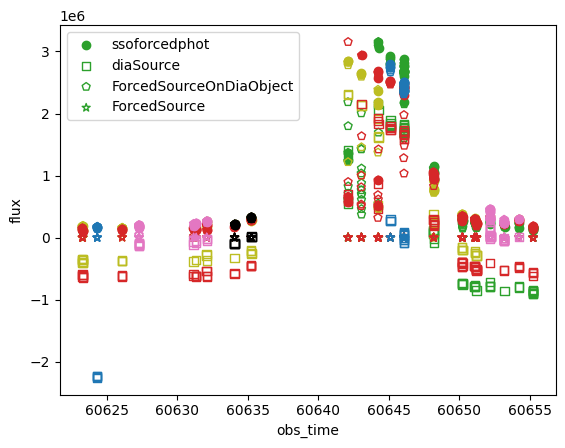

In [26]:
# plot the fluxes from the different photometry methods

x_plot = "obs_time"
y_plot = "flux"

x_plot2 = "midpointMjdTai"
y_plot2 = "apFlux"

x_plot3 = "expMidptMJD"
y_plot3 = "psfFlux"

df_plot = df_phot # ssoforcedphot measurements
df_plot2 = df_dia # DP1 DiaSource table
df_plot3 = df_forced1 # DP1 ForcedSourceOnDiaObject table
df_plot4 = df_forced2 # DP1 ForcedSource table

fig = plt.figure()
gs = gridspec.GridSpec(1, 1)
ax1 = plt.subplot(gs[0,0])

for i,filt in enumerate(np.unique(df_plot["band"])):
    _df_plot = df_plot[df_plot["band"]==filt]
    ax1.scatter(_df_plot[x_plot], _df_plot[y_plot], c = filt_col[filt], label = "ssoforcedphot")#,label = filt)

    _df_plot2 = df_plot2[df_plot2["band"]==filt]
    ax1.scatter(_df_plot2[x_plot2], _df_plot2[y_plot2], marker = "s", edgecolor = filt_col[filt], facecolor = "none", label = "diaSource")

    _df_plot3 = df_plot3[df_plot3["band"]==filt]
    ax1.scatter(_df_plot3[x_plot3], _df_plot3[y_plot3], marker = "p", edgecolor = filt_col[filt], facecolor = "none", label = "ForcedSourceOnDiaObject")

    _df_plot4 = df_plot4[df_plot4["band"]==filt]
    ax1.scatter(_df_plot4[x_plot3], _df_plot4[y_plot3], marker = "*", edgecolor = filt_col[filt], facecolor = "none", label = "ForcedSource")

    if i==0:
        ax1.legend()

ax1.set_xlabel(x_plot)
ax1.set_ylabel(y_plot)

plt.show()

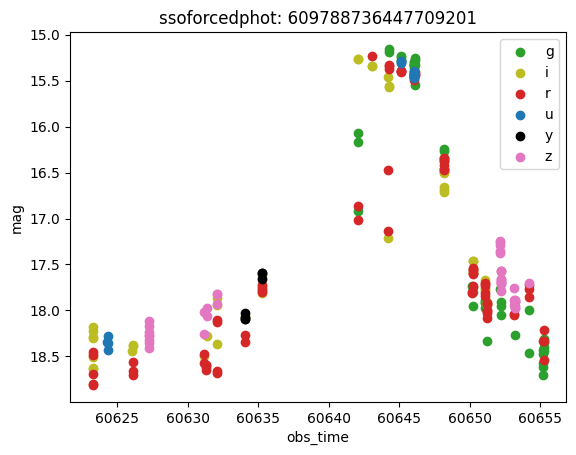

In [27]:
# plot the ssoforced phot magnitude lightcurve

x_plot = "obs_time"
y_plot = "mag"
df_plot = df_phot

fig = plt.figure()
gs = gridspec.GridSpec(1, 1)
ax1 = plt.subplot(gs[0,0])

for i,filt in enumerate(np.unique(df_plot["band"])):
    _df_plot = df_plot[df_plot["band"]==filt]
    ax1.scatter(_df_plot[x_plot], _df_plot[y_plot], c = filt_col[filt], label = filt)

ax1.set_xlabel(x_plot)
ax1.set_ylabel(y_plot)
ax1.invert_yaxis()
ax1.legend()

plt.title("ssoforcedphot: {}".format(diaObjectId))

plt.show()

# Issue with ssoforcedphot timings?

In [28]:
list(df_forced1)

['diaObjectId',
 'nDiaSources',
 'expMidptMJD',
 'expTime',
 'band',
 'coord_dec',
 'coord_ra',
 'detector',
 'diaObjectId2',
 'diff_PixelFlags_nodataCenter',
 'invalidPsfFlag',
 'parentObjectId',
 'patch',
 'pixelFlags_bad',
 'pixelFlags_cr',
 'pixelFlags_crCenter',
 'pixelFlags_edge',
 'pixelFlags_interpolated',
 'pixelFlags_interpolatedCenter',
 'pixelFlags_nodata',
 'pixelFlags_saturated',
 'pixelFlags_saturatedCenter',
 'pixelFlags_suspect',
 'pixelFlags_suspectCenter',
 'psfDiffFlux',
 'psfDiffFluxErr',
 'psfDiffFlux_flag',
 'psfFlux',
 'psfFluxErr',
 'psfFlux_flag',
 'tract',
 'visit',
 'psfMag',
 'psfDiffMag']

In [29]:
# Combine the ssoforcedphot results with the dp1 forced photometry results
_df_time = df_phot.merge(df_forced1, how = "left", left_on = "visit_id", right_on = "visit")
_df_time[['obs_time','expMidptMJD','expTime']]

,obs_time,expMidptMJD,expTime
0,60646.068016,60646.068236,38.0
1,60646.065583,60646.065803,38.0
2,60646.066800,60646.067020,38.0
3,60646.073508,60646.073681,30.0
4,60646.062369,60646.062543,30.0
...,...,...,...
232,60650.228484,60650.228658,30.0
233,60650.214755,60650.214928,30.0
234,60650.223227,60650.223401,30.0
235,60650.224749,60650.224923,30.0


In [30]:
# the time difference seems to correspond to half expTime?
(np.array(_df_time['obs_time'] - _df_time['expMidptMJD']) * u.d).to(u.s).value

array([-18.99999941, -19.00000004, -19.00000004, -14.99999973,
       -14.99999973, -14.99999973, -19.00000004, -14.99999911,
       -14.99999973, -14.99999973, -14.99999973, -14.99999973,
       -14.99999973, -19.00000004, -14.99999973, -19.00000067,
       -14.99999973, -14.99999973, -14.99999973, -19.00000004,
       -14.99999911, -14.99999973, -14.99999911, -14.99999973,
       -14.99999973, -14.99999973, -14.99999973, -14.99999973,
       -19.00000004, -14.99999973, -14.99999973, -14.99999973,
       -14.99999973, -14.99999973, -14.99999973, -15.00000036,
       -14.99999973, -14.99999973, -14.99999973, -14.99999973,
       -14.99999973, -14.99999973, -14.99999973, -14.99999973,
       -14.99999973, -14.99999911, -14.99999973, -14.99999973,
       -14.99999911, -14.99999973, -14.99999973, -14.99999911,
       -14.99999973, -14.99999973, -14.99999973, -14.99999973,
       -14.99999973, -14.99999973, -14.99999973, -14.99999973,
       -14.99999973, -14.99999973, -14.99999973, -14.99

# Issue with additional sources detected in error ellipse

In [31]:
# read in the json results file
_df = pd.read_json(fname_json, convert_dates = False)
_df["original_index"] = _df.index
_df = _df.explode("phot_within_error_ellipse")
_df

,target_name,target_type,image_type,ephemeris_service,visit_id,detector_id,band,coordinates_central,obs_time,cutout_size,saved_image_name,uncertainty,forced_phot_on_target,phot_within_error_ellipse,original_index
0,609788736447709184,standalone,visit_image,N/A,2024120100155,2,u,"[53.45738556095445, -28.378704517611503]",60646.068016,800,609788736447709201_visit2024120100155_detector...,"{'rss': 20.0, 'smaa': 20.0, 'smia': 20.0, 'the...","{'ra': 53.45738556095445, 'dec': -28.378704517...","{'ra': 53.459131771294935, 'dec': -28.38132663...",0
0,609788736447709184,standalone,visit_image,N/A,2024120100155,2,u,"[53.45738556095445, -28.378704517611503]",60646.068016,800,609788736447709201_visit2024120100155_detector...,"{'rss': 20.0, 'smaa': 20.0, 'smia': 20.0, 'the...","{'ra': 53.45738556095445, 'dec': -28.378704517...","{'ra': 53.45330083815732, 'dec': -28.381702653...",0
1,609788736447709184,standalone,visit_image,N/A,2024120100151,2,u,"[53.45738556095445, -28.378704517611503]",60646.065583,800,609788736447709201_visit2024120100151_detector...,"{'rss': 20.0, 'smaa': 20.0, 'smia': 20.0, 'the...","{'ra': 53.45738556095445, 'dec': -28.378704517...","{'ra': 53.45738648494485, 'dec': -28.378712403...",1
1,609788736447709184,standalone,visit_image,N/A,2024120100151,2,u,"[53.45738556095445, -28.378704517611503]",60646.065583,800,609788736447709201_visit2024120100151_detector...,"{'rss': 20.0, 'smaa': 20.0, 'smia': 20.0, 'the...","{'ra': 53.45738556095445, 'dec': -28.378704517...","{'ra': 53.456703089472484, 'dec': -28.37609768...",1
1,609788736447709184,standalone,visit_image,N/A,2024120100151,2,u,"[53.45738556095445, -28.378704517611503]",60646.065583,800,609788736447709201_visit2024120100151_detector...,"{'rss': 20.0, 'smaa': 20.0, 'smia': 20.0, 'the...","{'ra': 53.45738556095445, 'dec': -28.378704517...","{'ra': 53.46026561751023, 'dec': -28.380026549...",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236,609788736447709184,standalone,visit_image,N/A,2024120500095,6,i,"[53.45738556095445, -28.378704517611503]",60650.220919,800,609788736447709201_visit2024120500095_detector...,"{'rss': 20.0, 'smaa': 20.0, 'smia': 20.0, 'the...","{'ra': 53.45738556095445, 'dec': -28.378704517...","{'ra': 53.45977395245907, 'dec': -28.376627461...",236
236,609788736447709184,standalone,visit_image,N/A,2024120500095,6,i,"[53.45738556095445, -28.378704517611503]",60650.220919,800,609788736447709201_visit2024120500095_detector...,"{'rss': 20.0, 'smaa': 20.0, 'smia': 20.0, 'the...","{'ra': 53.45738556095445, 'dec': -28.378704517...","{'ra': 53.45755093277779, 'dec': -28.375505782...",236
236,609788736447709184,standalone,visit_image,N/A,2024120500095,6,i,"[53.45738556095445, -28.378704517611503]",60650.220919,800,609788736447709201_visit2024120500095_detector...,"{'rss': 20.0, 'smaa': 20.0, 'smia': 20.0, 'the...","{'ra': 53.45738556095445, 'dec': -28.378704517...","{'ra': 53.46077813327155, 'dec': -28.376021604...",236
236,609788736447709184,standalone,visit_image,N/A,2024120500095,6,i,"[53.45738556095445, -28.378704517611503]",60650.220919,800,609788736447709201_visit2024120500095_detector...,"{'rss': 20.0, 'smaa': 20.0, 'smia': 20.0, 'the...","{'ra': 53.45738556095445, 'dec': -28.378704517...","{'ra': 53.45450537006487, 'dec': -28.375245046...",236


In [32]:
# expand the json format dataframe to get the forced_phot_on_target data
_df_forced = pd.json_normalize(_df["forced_phot_on_target"])
old_cols = _df_forced.columns
new_cols = ["forced_phot_on_target." + x for x in old_cols]
rename_dict = {}
for i in range(len(old_cols)):
    rename_dict[old_cols[i]] = new_cols[i]
_df_forced = _df_forced.rename(rename_dict, axis = 1)
_df_forced

,forced_phot_on_target.ra,forced_phot_on_target.dec,forced_phot_on_target.ra_err,forced_phot_on_target.dec_err,forced_phot_on_target.x,forced_phot_on_target.y,forced_phot_on_target.x_err,forced_phot_on_target.y_err,forced_phot_on_target.snr,forced_phot_on_target.flux,forced_phot_on_target.flux_err,forced_phot_on_target.mag,forced_phot_on_target.mag_err,forced_phot_on_target.separation,forced_phot_on_target.sigma
0,53.457386,-28.378705,0,0,3524.745070,2232.229391,0,0,776.131368,2.354927e+06,3034.186513,15.470056,0.001399,0,0
1,53.457386,-28.378705,0,0,3524.745070,2232.229391,0,0,776.131368,2.354927e+06,3034.186513,15.470056,0.001399,0,0
2,53.457386,-28.378705,0,0,2211.115979,572.895065,0,0,776.698564,2.371910e+06,3053.835810,15.462255,0.001398,0,0
3,53.457386,-28.378705,0,0,2211.115979,572.895065,0,0,776.698564,2.371910e+06,3053.835810,15.462255,0.001398,0,0
4,53.457386,-28.378705,0,0,2211.115979,572.895065,0,0,776.698564,2.371910e+06,3053.835810,15.462255,0.001398,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1453,53.457386,-28.378705,0,0,3470.945426,3934.570441,0,0,523.107688,3.325473e+05,635.714809,17.595366,0.002076,0,0
1454,53.457386,-28.378705,0,0,3470.945426,3934.570441,0,0,523.107688,3.325473e+05,635.714809,17.595366,0.002076,0,0
1455,53.457386,-28.378705,0,0,3470.945426,3934.570441,0,0,523.107688,3.325473e+05,635.714809,17.595366,0.002076,0,0
1456,53.457386,-28.378705,0,0,3470.945426,3934.570441,0,0,523.107688,3.325473e+05,635.714809,17.595366,0.002076,0,0


In [33]:
# expand the json format dataframe to get the phot_within_error_ellipse data
_df_ellipse = pd.json_normalize(_df["phot_within_error_ellipse"])
old_cols = _df_ellipse.columns
new_cols = ["phot_within_error_ellipse." + x for x in old_cols]
rename_dict = {}
for i in range(len(old_cols)):
    rename_dict[old_cols[i]] = new_cols[i]
_df_ellipse = _df_ellipse.rename(rename_dict, axis = 1)
_df_ellipse

,phot_within_error_ellipse.ra,phot_within_error_ellipse.dec,phot_within_error_ellipse.ra_err,phot_within_error_ellipse.dec_err,phot_within_error_ellipse.x,phot_within_error_ellipse.y,phot_within_error_ellipse.x_err,phot_within_error_ellipse.y_err,phot_within_error_ellipse.snr,phot_within_error_ellipse.flux,phot_within_error_ellipse.flux_err,phot_within_error_ellipse.mag,phot_within_error_ellipse.mag_err,phot_within_error_ellipse.separation,phot_within_error_ellipse.sigma
0,53.459132,-28.381327,0.000000e+00,0.000000e+00,3572.000000,2205.000000,0.0,0.0,3.759500,1.393939e+03,370.777731,23.539391,0.288798,10.940606,1.641091
1,53.453301,-28.381703,2.511659e-06,2.278118e-06,3578.135990,2297.187936,0.0,0.0,3.549491,1.319999e+03,371.883873,23.598566,0.305885,16.848676,2.527301
2,53.457386,-28.378712,4.549743e-09,4.366419e-09,2211.257676,572.881319,0.0,0.0,776.679799,2.374199e+06,3056.857030,15.461207,0.001398,0.028540,0.004281
3,53.456703,-28.376098,6.340470e-07,7.960553e-07,2164.244030,583.395541,0.0,0.0,3.854319,1.231518e+03,319.516442,23.673898,0.281693,9.630340,1.444551
4,53.460266,-28.380027,7.359857e-07,5.268049e-07,2235.094949,527.542025,0.0,0.0,3.902773,1.250777e+03,320.484093,23.657051,0.278196,10.289058,1.543359
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1453,53.459774,-28.376627,4.373101e-07,4.801894e-07,3523.823358,3939.470672,0.0,0.0,6.294315,1.281281e+03,203.561666,23.630889,0.172495,10.636763,1.595514
1454,53.457551,-28.375506,1.538349e-06,1.916245e-06,3516.622497,3899.621075,0.0,0.0,3.403017,6.953494e+02,204.333201,24.294492,0.319051,11.527353,1.729103
1455,53.460778,-28.376022,7.654502e-07,9.484659e-07,3542.377526,3944.620314,0.0,0.0,3.693897,7.497089e+02,202.958823,24.212768,0.293927,14.448384,2.167258
1456,53.454505,-28.375245,6.251820e-07,7.704552e-07,3489.206519,3859.765202,0.0,0.0,4.376301,8.920061e+02,203.826498,24.024080,0.248094,15.437929,2.315689


In [34]:
# combine the forced_phot_on_target and phot_within_error_ellipse dataframes into one large dataframe
_df = _df.reset_index(drop=True).drop(["forced_phot_on_target","phot_within_error_ellipse"],axis = 1)
_df = pd.concat([_df,_df_forced,_df_ellipse],axis = 1)

In [35]:
_df

,target_name,target_type,image_type,ephemeris_service,visit_id,detector_id,band,coordinates_central,obs_time,cutout_size,...,phot_within_error_ellipse.y,phot_within_error_ellipse.x_err,phot_within_error_ellipse.y_err,phot_within_error_ellipse.snr,phot_within_error_ellipse.flux,phot_within_error_ellipse.flux_err,phot_within_error_ellipse.mag,phot_within_error_ellipse.mag_err,phot_within_error_ellipse.separation,phot_within_error_ellipse.sigma
0,609788736447709184,standalone,visit_image,N/A,2024120100155,2,u,"[53.45738556095445, -28.378704517611503]",60646.068016,800,...,2205.000000,0.0,0.0,3.759500,1.393939e+03,370.777731,23.539391,0.288798,10.940606,1.641091
1,609788736447709184,standalone,visit_image,N/A,2024120100155,2,u,"[53.45738556095445, -28.378704517611503]",60646.068016,800,...,2297.187936,0.0,0.0,3.549491,1.319999e+03,371.883873,23.598566,0.305885,16.848676,2.527301
2,609788736447709184,standalone,visit_image,N/A,2024120100151,2,u,"[53.45738556095445, -28.378704517611503]",60646.065583,800,...,572.881319,0.0,0.0,776.679799,2.374199e+06,3056.857030,15.461207,0.001398,0.028540,0.004281
3,609788736447709184,standalone,visit_image,N/A,2024120100151,2,u,"[53.45738556095445, -28.378704517611503]",60646.065583,800,...,583.395541,0.0,0.0,3.854319,1.231518e+03,319.516442,23.673898,0.281693,9.630340,1.444551
4,609788736447709184,standalone,visit_image,N/A,2024120100151,2,u,"[53.45738556095445, -28.378704517611503]",60646.065583,800,...,527.542025,0.0,0.0,3.902773,1.250777e+03,320.484093,23.657051,0.278196,10.289058,1.543359
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1453,609788736447709184,standalone,visit_image,N/A,2024120500095,6,i,"[53.45738556095445, -28.378704517611503]",60650.220919,800,...,3939.470672,0.0,0.0,6.294315,1.281281e+03,203.561666,23.630889,0.172495,10.636763,1.595514
1454,609788736447709184,standalone,visit_image,N/A,2024120500095,6,i,"[53.45738556095445, -28.378704517611503]",60650.220919,800,...,3899.621075,0.0,0.0,3.403017,6.953494e+02,204.333201,24.294492,0.319051,11.527353,1.729103
1455,609788736447709184,standalone,visit_image,N/A,2024120500095,6,i,"[53.45738556095445, -28.378704517611503]",60650.220919,800,...,3944.620314,0.0,0.0,3.693897,7.497089e+02,202.958823,24.212768,0.293927,14.448384,2.167258
1456,609788736447709184,standalone,visit_image,N/A,2024120500095,6,i,"[53.45738556095445, -28.378704517611503]",60650.220919,800,...,3859.765202,0.0,0.0,4.376301,8.920061e+02,203.826498,24.024080,0.248094,15.437929,2.315689


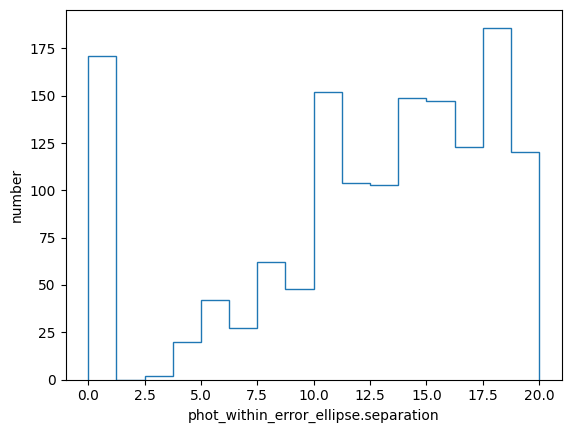

In [36]:
# plot distribution of all separations across all visits
x_plot = "phot_within_error_ellipse.separation"
df_plot = _df

fig = plt.figure()
gs = gridspec.GridSpec(1, 1)
ax1 = plt.subplot(gs[0,0])

ax1.hist(df_plot[x_plot], bins = 'auto', histtype = "step")

ax1.set_xlabel(x_plot)
ax1.set_ylabel("number")

plt.show()

In [37]:
# get the smallest phot_within_error_ellipse.separation for each visit
_df_min = _df.groupby(["visit_id","detector_id"]).min("phot_within_error_ellipse.separation").reset_index()
_df_min

,visit_id,detector_id,target_name,obs_time,cutout_size,original_index,forced_phot_on_target.ra,forced_phot_on_target.dec,forced_phot_on_target.ra_err,forced_phot_on_target.dec_err,...,phot_within_error_ellipse.y,phot_within_error_ellipse.x_err,phot_within_error_ellipse.y_err,phot_within_error_ellipse.snr,phot_within_error_ellipse.flux,phot_within_error_ellipse.flux_err,phot_within_error_ellipse.mag,phot_within_error_ellipse.mag_err,phot_within_error_ellipse.separation,phot_within_error_ellipse.sigma
0,2024110800245,6,609788736447709184,60623.258347,800,96,53.457386,-28.378705,0,0,...,1232.520684,0.0,0.0,3.232553,662.586947,204.368400,18.223930,0.002886,0.017123,0.002568
1,2024110800246,6,609788736447709184,60623.259155,800,97,53.457386,-28.378705,0,0,...,1210.753747,0.0,0.0,3.809714,540.482597,141.869615,18.449546,0.002836,0.021693,0.003254
2,2024110800247,6,609788736447709184,60623.259722,800,100,53.457386,-28.378705,0,0,...,3847.429668,0.0,0.0,3.449071,476.395275,138.122797,18.488560,0.002857,0.022325,0.003349
3,2024110800248,6,609788736447709184,60623.260565,800,101,53.457386,-28.378705,0,0,...,3842.000000,0.0,0.0,3.334335,702.875194,209.177709,18.286373,0.003006,0.028234,0.004235
4,2024110800249,6,609788736447709184,60623.261133,800,99,53.457386,-28.378705,0,0,...,2839.108352,0.0,0.0,3.106013,642.781190,206.947380,22.905162,0.092026,4.337488,0.650623
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232,2024121000425,6,609788736447709184,60655.245875,800,114,53.457386,-28.378705,0,0,...,2507.937400,0.0,0.0,2.938018,26587.224088,8874.552311,18.204992,0.051726,0.042345,0.006352
233,2024121000427,6,609788736447709184,60655.247037,800,115,53.457386,-28.378705,0,0,...,3819.372543,0.0,0.0,130.865877,156697.735239,1197.391858,18.412343,0.008297,0.074873,0.011231
234,2024121000430,7,609788736447709184,60655.248206,800,188,53.457386,-28.378705,0,0,...,3371.000000,0.0,0.0,3.226353,2674.459128,822.600140,18.338408,0.006367,0.063291,0.009494
235,2024121000433,6,609788736447709184,60655.249408,800,116,53.457386,-28.378705,0,0,...,2786.000000,0.0,0.0,2.761235,2302.865553,833.153324,18.305265,0.006277,0.066004,0.009901


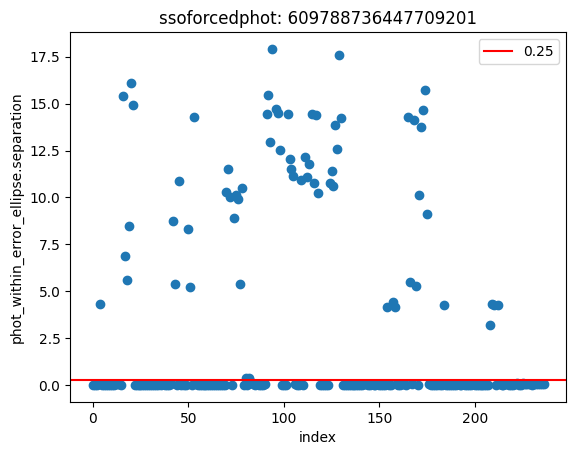

In [38]:
# plot the smallest separation between phot_within_error_ellipse and forced_phot_on_target for each visit
y_plot = "phot_within_error_ellipse.separation"
df_plot = _df_min

fig = plt.figure()
gs = gridspec.GridSpec(1, 1)
ax1 = plt.subplot(gs[0,0])

ax1.scatter(np.arange(len(df_plot)),df_plot[y_plot])

sep = 0.25
ax1.axhline(sep, c = "r", label = sep)

ax1.set_xlabel("index")
ax1.set_ylabel(y_plot)
ax1.legend()

plt.title("ssoforcedphot: {}".format(diaObjectId))

plt.show()

In [39]:
# find the visits with the greatest separation
_df_min[_df_min["phot_within_error_ellipse.separation"]>1.0].sort_values("phot_within_error_ellipse.separation")[["phot_within_error_ellipse.separation","visit_id","detector_id"]]


,phot_within_error_ellipse.separation,visit_id,detector_id
208,3.188816,2024120800362,6
158,4.143900,2024120500100,6
154,4.156932,2024120500083,6
184,4.240599,2024120600274,3
210,4.276304,2024120800369,6
...,...,...,...
92,15.433089,2024113000163,2
174,15.746281,2024120600097,5
20,16.077442,2024111100085,5
129,17.567431,2024120100201,2


In [40]:
# select a visit_id with a large separation
if diaObjectId==609788736447709201:
    # example_visit_id = 2024113000165
    example_visit_id = 2024120500100
elif diaObjectId==609781520902651937:
    example_visit_id = 2024120100149
else:
    example_visit_id = None

In [41]:
# look up the corresponding cutout image
_df[_df['visit_id']==example_visit_id].iloc[0]["saved_image_name"]

'609788736447709201_visit2024120500100_detector6_bandi'

In [42]:
# Inspect the closest phot_within_error_ellipse source to forced_phot_on_target
_df_min[_df_min['visit_id']==example_visit_id]

,visit_id,detector_id,target_name,obs_time,cutout_size,original_index,forced_phot_on_target.ra,forced_phot_on_target.dec,forced_phot_on_target.ra_err,forced_phot_on_target.dec_err,...,phot_within_error_ellipse.y,phot_within_error_ellipse.x_err,phot_within_error_ellipse.y_err,phot_within_error_ellipse.snr,phot_within_error_ellipse.flux,phot_within_error_ellipse.flux_err,phot_within_error_ellipse.mag,phot_within_error_ellipse.mag_err,phot_within_error_ellipse.separation,phot_within_error_ellipse.sigma
158,2024120500100,6,609788736447709184,60650.223227,800,234,53.457386,-28.378705,0,0,...,420.237113,0.0,0.0,3.088592,676.180744,218.875967,23.272268,0.134415,4.1439,0.621585


In [43]:
# inspect all phot_within_error_ellipse sources measured in visit_id
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(_df[_df["visit_id"]==example_visit_id])

,target_name,target_type,image_type,ephemeris_service,visit_id,detector_id,band,coordinates_central,obs_time,cutout_size,saved_image_name,uncertainty,original_index,forced_phot_on_target.ra,forced_phot_on_target.dec,forced_phot_on_target.ra_err,forced_phot_on_target.dec_err,forced_phot_on_target.x,forced_phot_on_target.y,forced_phot_on_target.x_err,forced_phot_on_target.y_err,forced_phot_on_target.snr,forced_phot_on_target.flux,forced_phot_on_target.flux_err,forced_phot_on_target.mag,forced_phot_on_target.mag_err,forced_phot_on_target.separation,forced_phot_on_target.sigma,phot_within_error_ellipse.ra,phot_within_error_ellipse.dec,phot_within_error_ellipse.ra_err,phot_within_error_ellipse.dec_err,phot_within_error_ellipse.x,phot_within_error_ellipse.y,phot_within_error_ellipse.x_err,phot_within_error_ellipse.y_err,phot_within_error_ellipse.snr,phot_within_error_ellipse.flux,phot_within_error_ellipse.flux_err,phot_within_error_ellipse.mag,phot_within_error_ellipse.mag_err,phot_within_error_ellipse.separation,phot_within_error_ellipse.sigma
1435,609788736447709184,standalone,visit_image,N/A,2024120500100,6,i,"[53.45738556095445, -28.378704517611503]",60650.223227,800,609788736447709201_visit2024120500100_detector...,"{'rss': 20.0, 'smaa': 20.0, 'smia': 20.0, 'the...",234,53.457386,-28.378705,0,0,1268.837111,491.313404,0,0,528.668415,333928.28663,631.640319,17.590867,0.002054,0,0,53.457076,-28.379823,0.000000e+00,0.000000e+00,1253.000000,478.000000,0.0,0.0,8.077479,1782.759502,220.707419,23.272268,0.134415,4.143900,0.621585
1436,609788736447709184,standalone,visit_image,N/A,2024120500100,6,i,"[53.45738556095445, -28.378704517611503]",60650.223227,800,609788736447709201_visit2024120500100_detector...,"{'rss': 20.0, 'smaa': 20.0, 'smia': 20.0, 'the...",234,53.457386,-28.378705,0,0,1268.837111,491.313404,0,0,528.668415,333928.28663,631.640319,17.590867,0.002054,0,0,53.458749,-28.376362,5.653651e-07,6.973025e-07,1296.980912,529.336068,0.0,0.0,3.452024,755.852616,218.959281,24.203907,0.314522,9.474071,1.421111
1437,609788736447709184,standalone,visit_image,N/A,2024120500100,6,i,"[53.45738556095445, -28.378704517611503]",60650.223227,800,609788736447709201_visit2024120500100_detector...,"{'rss': 20.0, 'smaa': 20.0, 'smia': 20.0, 'the...",234,53.457386,-28.378705,0,0,1268.837111,491.313404,0,0,528.668415,333928.28663,631.640319,17.590867,0.002054,0,0,53.459781,-28.376634,1.654277e-06,1.555017e-06,1285.363020,541.792975,0.0,0.0,5.725145,1258.460505,219.812845,23.650401,0.189643,10.637921,1.595688
1438,609788736447709184,standalone,visit_image,N/A,2024120500100,6,i,"[53.45738556095445, -28.378704517611503]",60650.223227,800,609788736447709201_visit2024120500100_detector...,"{'rss': 20.0, 'smaa': 20.0, 'smia': 20.0, 'the...",234,53.457386,-28.378705,0,0,1268.837111,491.313404,0,0,528.668415,333928.28663,631.640319,17.590867,0.002054,0,0,53.459090,-28.375494,6.728974e-07,6.465704e-07,1308.557862,541.099086,0.0,0.0,3.442473,753.474712,218.875967,24.207328,0.315394,12.755469,1.913320
1439,609788736447709184,standalone,visit_image,N/A,2024120500100,6,i,"[53.45738556095445, -28.378704517611503]",60650.223227,800,609788736447709201_visit2024120500100_detector...,"{'rss': 20.0, 'smaa': 20.0, 'smia': 20.0, 'the...",234,53.457386,-28.378705,0,0,1268.837111,491.313404,0,0,528.668415,333928.28663,631.640319,17.590867,0.002054,0,0,53.452993,-28.379814,5.371169e-07,5.679568e-07,1281.803667,420.237113,0.0,0.0,4.305213,944.234175,219.323462,23.962301,0.252191,14.473067,2.170960
1440,609788736447709184,standalone,visit_image,N/A,2024120500100,6,i,"[53.45738556095445, -28.378704517611503]",60650.223227,800,609788736447709201_visit2024120500100_detector...,"{'rss': 20.0, 'smaa': 20.0, 'smia': 20.0, 'the...",234,53.457386,-28.378705,0,0,1268.837111,491.313404,0,0,528.668415,333928.28663,631.640319,17.590867,0.002054,0,0,53.462156,-28.380535,8.388747e-07,9.978817e-07,1205.886415,544.269681,0.0,0.0,3.548531,777.440907,219.088091,24.173332,0.305968,16.484798,2.

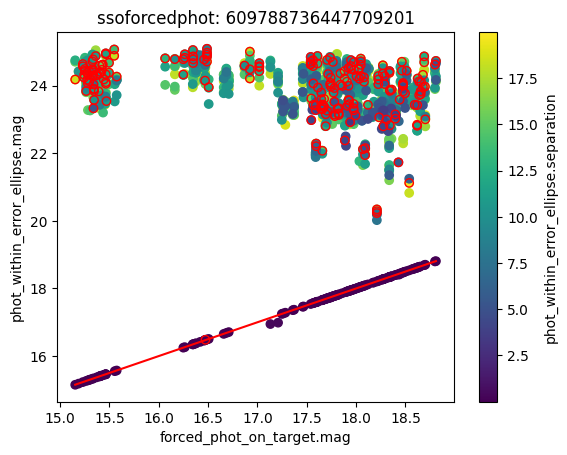

In [44]:
# compare the ssoforced forced_phot_on_target magnitude to phot_within_error_ellipse

x_plot = "forced_phot_on_target.mag"
y_plot = "phot_within_error_ellipse.mag"
c_plot = "phot_within_error_ellipse.separation"

df_plot = _df.sort_values(c_plot, ascending = False)
df_plot2 = _df[_df["phot_within_error_ellipse.ra_err"]==0]

fig = plt.figure()
gs = gridspec.GridSpec(1, 1)
ax1 = plt.subplot(gs[0,0])

s1 = ax1.scatter(df_plot[x_plot], df_plot[y_plot], c = df_plot[c_plot])
cbar1 = plt.colorbar(s1)

# highlight particular measurements - some outliers appear to have phot_within_error_ellipse.ra_err==0?
ax1.scatter(df_plot2[x_plot], df_plot2[y_plot], facecolor = "none", edgecolor = "r")

# plot the 1:1 line
ax1.plot([np.amin(df_plot[x_plot]),np.amax(df_plot[x_plot])],[np.amin(df_plot[x_plot]),np.amax(df_plot[x_plot])], c ="r")

cbar1.set_label(c_plot)
ax1.set_xlabel(x_plot)
ax1.set_ylabel(y_plot)

plt.title("ssoforcedphot: {}".format(diaObjectId))

plt.show()